In [3]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.4 MB/s eta 0:00:00


[*********************100%***********************]  1 of 1 completed


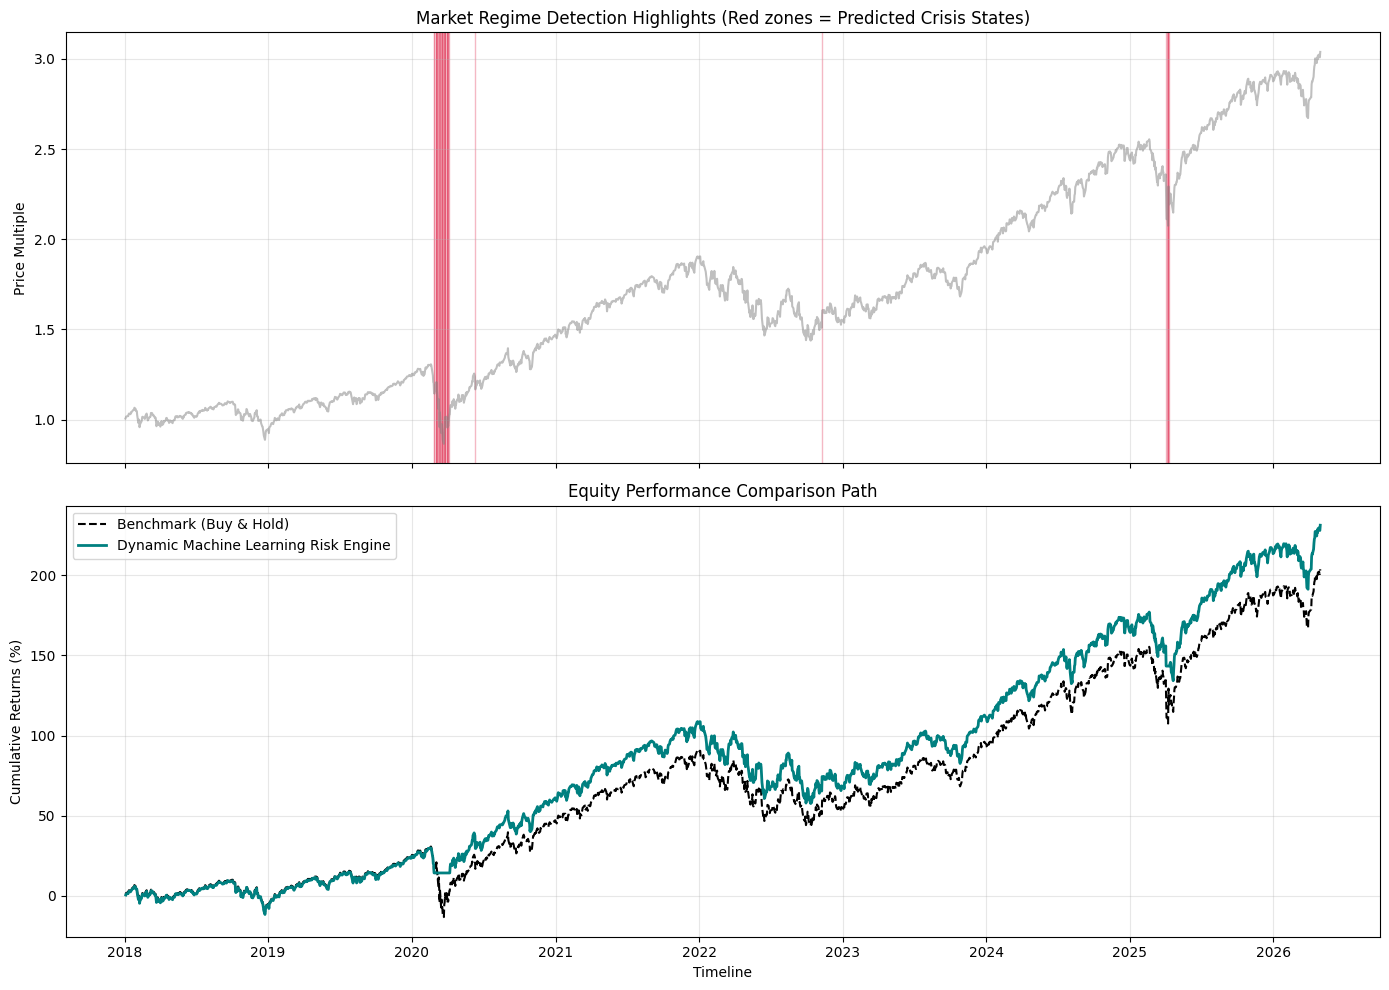

In [4]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM

# Suppress convergence warnings from underlying optimization loops
warnings.filterwarnings("ignore")


class RegimeSwitchingRiskEngine:

    def __init__(self, ticker, start_date, end_date, states=2):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.n_states = states
        self.data = None
        self.model = None

    def build_features(self):
        """Downloads historical market data and generates the model's feature

        matrix.
        """
        raw = yf.download(self.ticker, start=self.start_date, end=self.end_date)
        df = raw.dropna()

        # Isolate the core data vectors safely
        close_series = (
            df["Adj Close"] if "Adj Close" in df.columns else df["Close"]
        )
        high_series = df["High"]
        low_series = df["Low"]
        open_series = df["Open"]

        processed_df = pd.DataFrame(index=df.index)

        # Vector 1: Log Returns
        processed_df["Returns"] = np.log(
            close_series / close_series.shift(1)
        ).squeeze()

        # Vector 2: Garman-Klass Volatility Proxy
        log_hl = np.log(high_series / low_series) ** 2
        log_co = np.log(close_series / open_series) ** 2
        processed_df["GK_Vol"] = (
            (0.5 * log_hl - (2 * np.log(2) - 1) * log_co).squeeze().astype(float)
        )

        self.data = processed_df.dropna()

    def train_hmm(self):
        """Fits Gaussian HMM and maps the high-variance state consistently to State

        1.
        """
        # Format the 2D feature tracking matrix
        features = self.data[["Returns", "GK_Vol"]].values

        self.model = GaussianHMM(
            n_components=self.n_states, covariance_type="full", n_iter=1000, random_state=42
        )
        self.model.fit(features)

        # Predict current structural regimes
        hidden_states = self.model.predict(features)

        # Enforce structural labeling: State 1 must always represent the High Volatility Panic state
        state_variances = [
            np.diag(self.model.covars_[i])[1] for i in range(self.n_states)
        ]
        if state_variances[0] > state_variances[1]:
            # Flip states if mapping is inverted
            hidden_states = 1 - hidden_states
            self.model.means_ = self.model.means_[::-1]
            self.model.covars_ = self.model.covars_[::-1]

        self.data["Regime"] = hidden_states

    def run_risk_backtest(self):
        """Executes adaptive asset allocation based on the inferred market states

        matrix.
        """
        # Strategy Rules:
        # State 0 (Growth): 100% long allocation exposure
        # State 1 (Panic): De-leverage entirely to 0% cash protection
        self.data["Target_Weight"] = np.where(self.data["Regime"] == 0, 1.0, 0.0)

        # Shift weights by 1 day to prevent forward-looking data snooping bias
        self.data["Alloc_Weight"] = self.data["Target_Weight"].shift(1)

        # Strategy Performance Accounting
        self.data["Benchmark_Ret"] = self.data["Returns"]
        self.data["Strategy_Ret"] = (
            self.data["Alloc_Weight"] * self.data["Benchmark_Ret"]
        )

        # Cumulative Calculations
        self.data["Cum_Benchmark"] = np.exp(self.data["Benchmark_Ret"].cumsum()) - 1
        self.data["Cum_Strategy"] = np.exp(self.data["Strategy_Ret"].cumsum()) - 1

    def generate_analytics_dashboard(self):
        """Plots the regime inference classification and backtest equity path."""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # Plot 1: Regime classification over benchmark performance
        prices = np.exp(self.data["Returns"].cumsum())
        ax1.plot(prices.index, prices.values, color="gray", alpha=0.5, label=f"{self.ticker} Price")

        # Overlay color blocks for High Volatility Panic states
        panic_idx = self.data[self.data["Regime"] == 1].index
        for timestamp in panic_idx:
            ax1.axvspan(timestamp, timestamp, color="crimson", alpha=0.3)

        ax1.set_title(f"Market Regime Detection Highlights (Red zones = Predicted Crisis States)")
        ax1.set_ylabel("Price Multiple")
        ax1.grid(True, alpha=0.3)

        # Plot 2: Dynamic Strategy performance curves
        ax2.plot(self.data.index, self.data["Cum_Benchmark"] * 100, label="Benchmark (Buy & Hold)", color="black", linestyle="--")
        ax2.plot(self.data.index, self.data["Cum_Strategy"] * 100, label="Dynamic Machine Learning Risk Engine", color="teal", linewidth=2)
        ax2.set_title("Equity Performance Comparison Path")
        ax2.set_ylabel("Cumulative Returns (%)")
        ax2.set_xlabel("Timeline")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    # SPY serves as the systemic macroeconomic broad equity benchmark
    engine = RegimeSwitchingRiskEngine(
        ticker="SPY", start_date="2018-01-01", end_date="2026-05-01"
    )
    engine.build_features()
    engine.train_hmm()
    engine.run_risk_backtest()
    engine.generate_analytics_dashboard()

[*********************100%***********************]  1 of 1 completed


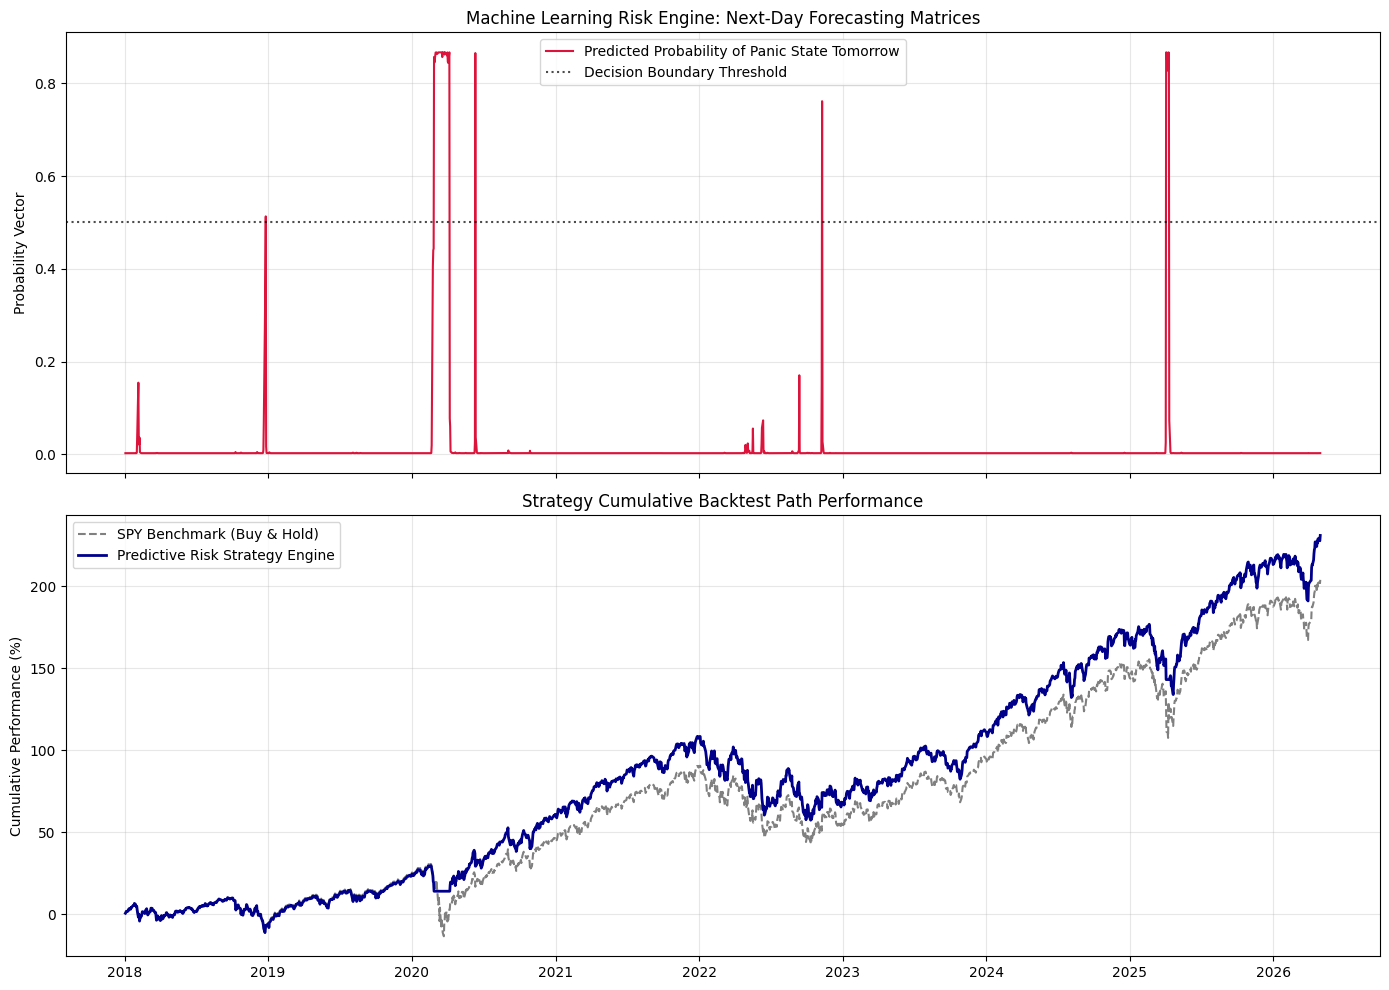

In [5]:
class PredictiveRiskEngine:

    def __init__(self, ticker, start, end):
        self.ticker = ticker
        self.start = start
        self.end = end
        self.data = None
        self.model = None

    def build_features(self):
        df = yf.download(self.ticker, start=self.start, end=self.end).dropna()
        close = df["Adj Close"] if "Adj Close" in df.columns else df["Close"]

        processed = pd.DataFrame(index=df.index)
        processed["Returns"] = np.log(close / close.shift(1)).squeeze()
        processed["GK_Vol"] = (
            (
                0.5 * np.log(df["High"] / df["Low"]) ** 2
                - (2 * np.log(2) - 1) * np.log(close / df["Open"]) ** 2
            )
            .squeeze()
            .astype(float)
        )

        self.data = processed.dropna()

    def train_and_predict(self):
        features = self.data[["Returns", "GK_Vol"]].values
        self.model = GaussianHMM(
            n_components=2, covariance_type="full", n_iter=1000, random_state=42
        )
        self.model.fit(features)

        # Ensure State 1 is always the high-volatility panic state
        state_vars = [np.diag(self.model.covars_[i])[1] for i in range(2)]
        flip = state_vars[0] > state_vars[1]
        if flip:
            self.model.means_ = self.model.means_[::-1]
            self.model.covars_ = self.model.covars_[::-1]

        # Calculate historical filtered state probabilities, shape: (N, 2)
        posteriors = self.model.predict_proba(features)
        if flip:
            posteriors = posteriors[:, ::-1]

        # Inferred state assignment
        self.data["Current_Regime"] = np.argmax(posteriors, axis=1)

        # Transition Matrix A calculation
        # A[i, j] = P(State_j at t+1 | State_i at t)
        A = self.model.transmat_
        if flip:
            A = np.flip(A)

        # Calculate One-Step-Ahead Forecast Matrix
        # Multiply current state distribution vector by transition probability columns
        tomorrow_pred = np.dot(posteriors, A)

        # Isolate the probability of shifting into or staying in Panic (State 1) tomorrow
        self.data["P_Panic_Tomorrow"] = tomorrow_pred[:, 1]

        # Shift predictive probabilities by 1 day to ensure it represents an actionable next-day signal
        self.data["Signal_Tomorrow"] = self.data["P_Panic_Tomorrow"].shift(1)

    def run_predictive_backtest(self, probability_cutoff=0.5):
        """If the predicted probability of a panic tomorrow breaches the

        cutoff, exit exposure entirely.
        """
        self.data["Alloc_Weight"] = np.where(
            self.data["Signal_Tomorrow"] > probability_cutoff, 0.0, 1.0
        )

        self.data["Benchmark_Ret"] = self.data["Returns"]
        self.data["Strategy_Ret"] = (
            self.data["Alloc_Weight"] * self.data["Benchmark_Ret"]
        )

        self.data["Cum_Benchmark"] = np.exp(self.data["Benchmark_Ret"].cumsum()) - 1
        self.data["Cum_Strategy"] = np.exp(self.data["Strategy_Ret"].cumsum()) - 1

    def generate_dashboard(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # Panel 1: Predictive Signal
        ax1.plot(
            self.data.index,
            self.data["P_Panic_Tomorrow"],
            color="crimson",
            label="Predicted Probability of Panic State Tomorrow",
        )
        ax1.axhline(0.5, color="black", linestyle=":", alpha=0.7, label="Decision Boundary Threshold")
        ax1.set_title("Machine Learning Risk Engine: Next-Day Forecasting Matrices")
        ax1.set_ylabel("Probability Vector")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Panel 2: Performance Output
        ax2.plot(self.data.index, self.data["Cum_Benchmark"] * 100, label="SPY Benchmark (Buy & Hold)", color="gray", linestyle="--")
        ax2.plot(self.data.index, self.data["Cum_Strategy"] * 100, label="Predictive Risk Strategy Engine", color="darkblue", linewidth=2)
        ax2.set_title("Strategy Cumulative Backtest Path Performance")
        ax2.set_ylabel("Cumulative Performance (%)")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    engine = PredictiveRiskEngine(
        ticker="SPY", start="2018-01-01", end="2026-05-01"
    )
    engine.build_features()
    engine.train_and_predict()
    engine.run_predictive_backtest(probability_cutoff=0.45)
    engine.generate_dashboard()

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


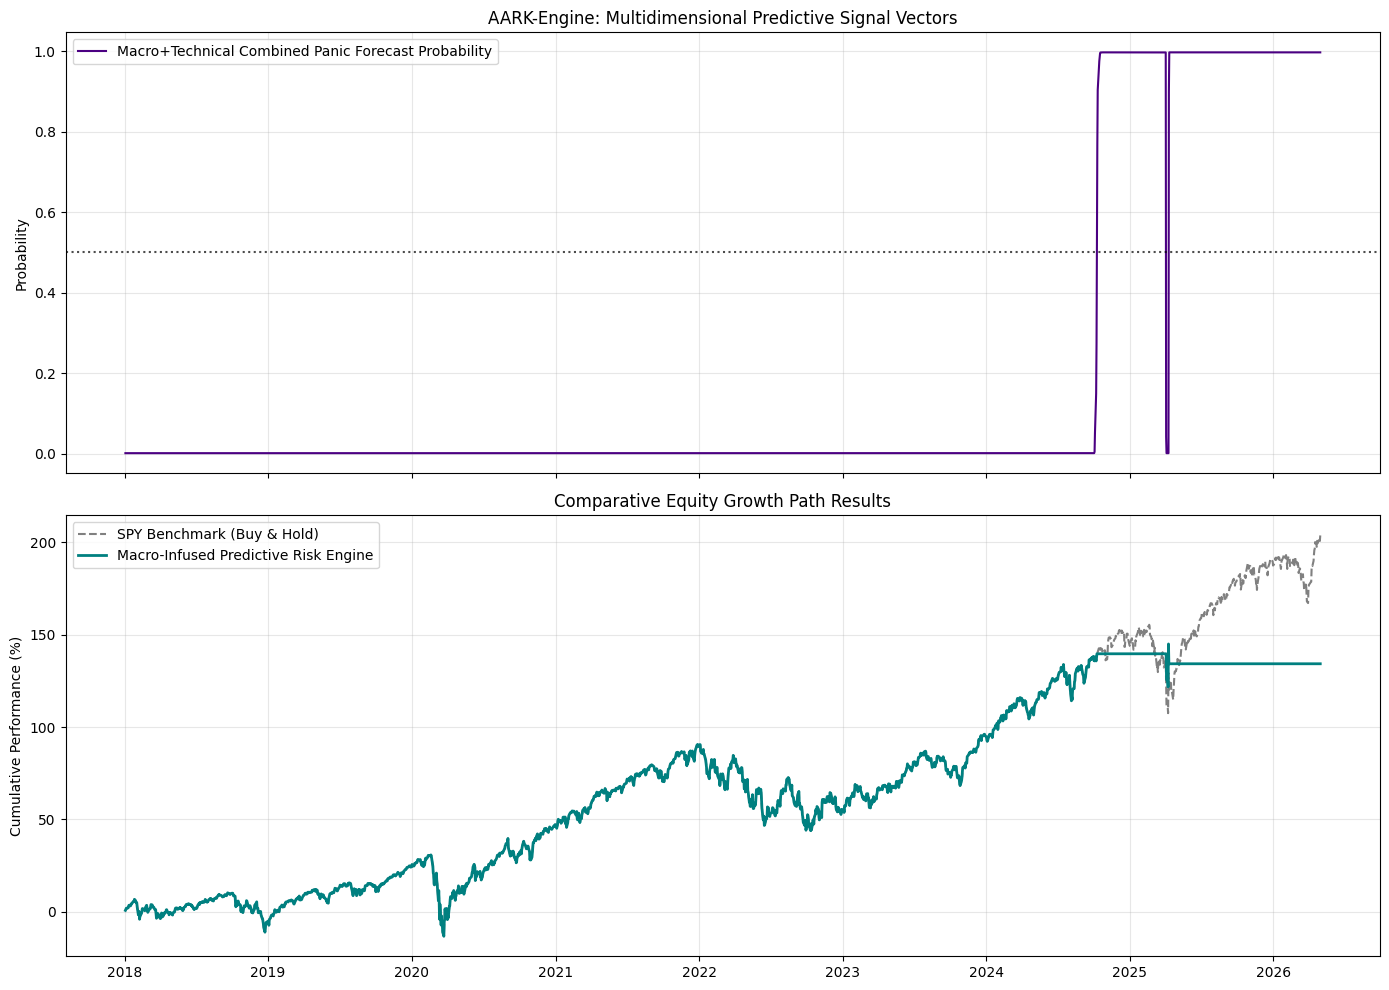

In [7]:
class InstitutionalRiskEngine:

    def __init__(self, benchmark, start, end):
        self.benchmark = benchmark
        self.start = start
        self.end = end
        self.data = None
        self.model = None

    def build_macro_feature_pipeline(self):
        """Downloads benchmark technicals and merges global alternative macro-

        sentiment vectors.
        """
        # Download all raw assets in a single batch call
        tickers = [self.benchmark, "HYG", "IEF", "GLD"]
        raw = yf.download(tickers, start=self.start, end=self.end)["Close"]
        df = raw.dropna()

        processed = pd.DataFrame(index=df.index)

        # 1. Benchmark Technical Vectors
        processed["Returns"] = np.log(
            df[self.benchmark] / df[self.benchmark].shift(1)
        )

        # Download high/low for the benchmark specifically to compute Garman-Klass Volatility
        bench_raw = yf.download(
            self.benchmark, start=self.start, end=self.end
        ).dropna()
        bench_close = (
            bench_raw["Adj Close"]
            if "Adj Close" in bench_raw.columns
            else bench_raw["Close"]
        )
        processed["GK_Vol"] = (
            (
                0.5 * np.log(bench_raw["High"] / bench_raw["Low"]) ** 2
                - (2 * np.log(2) - 1) * np.log(bench_close / bench_raw["Open"])
                ** 2
            )
            .squeeze()
            .astype(float)
        )

        # 2. Alternative Macro-Sentiment Vectors
        # Credit Distress Spread: Corporate High Yield minus Safe Treasuries
        processed["Credit_Distress"] = df["HYG"] / df["IEF"]

        # Safe-Haven Flight Vector: Gold strength relative to Equities
        processed["Gold_Flight"] = df["GLD"] / df[self.benchmark]

        self.data = processed.dropna()

    def train_multidimensional_hmm(self):
        """Fits a 4-Feature Gaussian HMM over technical and macro indicators."""
        feature_cols = ["Returns", "GK_Vol", "Credit_Distress", "Gold_Flight"]
        features = self.data[feature_cols].values

        # Initialize the Unsupervised clustering engine
        self.model = GaussianHMM(
            n_components=2, covariance_type="full", n_iter=2000, random_state=42
        )
        self.model.fit(features)

        # Enforce State 1 as the High Volatility / Distressed Market Regime
        state_vars = [np.diag(self.model.covars_[i])[1] for i in range(2)]
        flip = state_vars[0] > state_vars[1]
        if flip:
            self.model.means_ = self.model.means_[::-1]
            self.model.covars_ = self.model.covars_[::-1]

        posteriors = self.model.predict_proba(features)
        if flip:
            posteriors = posteriors[:, ::-1]

        # Map predictions into data arrays
        self.data["Current_Regime"] = np.argmax(posteriors, axis=1)

        # Calculate forward matrix transition predictions
        A = self.model.transmat_
        if flip:
            A = np.flip(A)

        tomorrow_pred = np.dot(posteriors, A)
        self.data["P_Panic_Tomorrow"] = tomorrow_pred[:, 1]
        self.data["Signal_Tomorrow"] = self.data["P_Panic_Tomorrow"].shift(1)

    def run_backtest(self, cutoff=0.5):
        """Executes risk mitigation rules driven by alternative data signatures."""
        self.data["Alloc_Weight"] = np.where(
            self.data["Signal_Tomorrow"] > cutoff, 0.0, 1.0
        )

        self.data["Benchmark_Ret"] = self.data["Returns"]
        self.data["Strategy_Ret"] = (
            self.data["Alloc_Weight"] * self.data["Benchmark_Ret"]
        )

        self.data["Cum_Benchmark"] = np.exp(self.data["Benchmark_Ret"].cumsum()) - 1
        self.data["Cum_Strategy"] = np.exp(self.data["Strategy_Ret"].cumsum()) - 1

    def generate_dashboard(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # Panel 1: Multidimensional Forecasting Probabilities
        ax1.plot(
            self.data.index,
            self.data["P_Panic_Tomorrow"],
            color="indigo",
            label="Macro+Technical Combined Panic Forecast Probability",
        )
        ax1.axhline(0.5, color="black", linestyle=":", alpha=0.7)
        ax1.set_title("AARK-Engine: Multidimensional Predictive Signal Vectors")
        ax1.set_ylabel("Probability")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Panel 2: Performance Evaluation Output
        ax2.plot(self.data.index, self.data["Cum_Benchmark"] * 100, label="SPY Benchmark (Buy & Hold)", color="gray", linestyle="--")
        ax2.plot(self.data.index, self.data["Cum_Strategy"] * 100, label="Macro-Infused Predictive Risk Engine", color="teal", linewidth=2)
        ax2.set_title("Comparative Equity Growth Path Results")
        ax2.set_ylabel("Cumulative Performance (%)")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    # Corrected keyword argument from 'ticker' to 'benchmark'
    engine = InstitutionalRiskEngine(
        benchmark="SPY", start="2018-01-01", end="2026-05-01"
    )
    engine.build_macro_feature_pipeline()
    engine.train_multidimensional_hmm()
    engine.run_backtest(cutoff=0.48)
    engine.generate_dashboard()